In [29]:
import os
import math
import time
import random
import json
from typing import Tuple, Dict, List
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from dataclasses import dataclass
from PIL import Image
from scipy import ndimage

# PyTorch
import torch
import torch.nn as nn
from torch.utils.data import DataLoader, random_split, Subset

# Датасеты / трансформации
import torchvision
from torchvision import transforms
from torchvision.models.segmentation import deeplabv3_resnet50, DeepLabV3_ResNet50_Weights
from torchvision.models import resnet18, ResNet18_Weights
from torchvision.transforms import functional as F
from torchvision.transforms import InterpolationMode
import torch.nn.functional as Fn
from torchvision.transforms.functional import to_pil_image, resize

print("torch:", torch.__version__)
print("torchvision:", torchvision.__version__)

torch: 2.10.0+cpu
torchvision: 0.25.0+cpu


In [42]:
def set_seed(seed: int = 42) -> None:
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)

    # Детеминизм (может замедлить)
    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark = False

RANDOM_STATE = 19
set_seed(RANDOM_STATE)

DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Device:", DEVICE)

FAST_MODE = True   # переключите на True для частичного датасета и более быстрого обучения
DATA_DIR = "./data"
EPOCHS = 5 if FAST_MODE else 12
BATCH_SIZE = 64

Device: cpu


### Часть A (S10): датасет для классификации изображений

In [3]:
STL10_MEAN = (0.4479, 0.4412, 0.4075)
STL10_STD  = (0.2600, 0.2564, 0.2708)

def get_stl10_transforms():
    # Базовый transform для CNN
    basic_transform = transforms.Compose([
        transforms.ToTensor(),
        transforms.Normalize(STL10_MEAN, STL10_STD)
    ])
    
    # Transform с аугментациями
    train_transform = transforms.Compose([
        transforms.RandomHorizontalFlip(),
        transforms.RandomCrop(96, padding=8),
        transforms.ColorJitter(brightness=0.2, contrast=0.2),
        transforms.ToTensor(),
        transforms.Normalize(STL10_MEAN, STL10_STD)
    ])
    
    # Preprocessing для pretrained ResNet
    resnet_transform = transforms.Compose([
        transforms.Resize((224, 224)),
        transforms.ToTensor(),
        transforms.Normalize(STL10_MEAN, STL10_STD)
    ])
    
    return basic_transform, train_transform, resnet_transform

basic_transform, train_transform, resnet_transform = get_stl10_transforms()

In [8]:
stl10_train = torchvision.datasets.STL10(
    root=DATA_DIR, 
    split='train', 
    transform=basic_transform, 
    download=True
)

stl10_test = torchvision.datasets.STL10(
    root=DATA_DIR, 
    split='test', 
    transform=basic_transform, 
    download=True
)

# Разделение train на train/val (80/20)
train_size = int(0.8 * len(stl10_train))
val_size = len(stl10_train) - train_size
stl10_train_split, stl10_val = random_split(
    stl10_train, [train_size, val_size], 
    generator=torch.Generator()
)

100.0%


In [9]:
batch_size = 64
train_loader_A = DataLoader(stl10_train_split, batch_size=batch_size, shuffle=True)
val_loader_A = DataLoader(stl10_val, batch_size=batch_size, shuffle=False)
test_loader_A = DataLoader(stl10_test, batch_size=batch_size, shuffle=False)
class_names_A = stl10_train.classes

print(f"Train: {len(train_loader_A.dataset)}, Val: {len(val_loader_A.dataset)}, Test: {len(test_loader_A.dataset)}")

Train: 4000, Val: 1000, Test: 8000


In [10]:
# Sanity-check для STL10
dataiter = iter(train_loader_A)
images, labels = next(dataiter)
    
print(f"Batch size: {images.shape}, Labels: {labels.shape}")
print(f"x.shape: {images.shape}, y.shape: {labels.shape}")
print(f"Classes: {class_names_A}")

Batch size: torch.Size([64, 3, 96, 96]), Labels: torch.Size([64])
x.shape: torch.Size([64, 3, 96, 96]), y.shape: torch.Size([64])
Classes: ['airplane', 'bird', 'car', 'cat', 'deer', 'dog', 'horse', 'monkey', 'ship', 'truck']


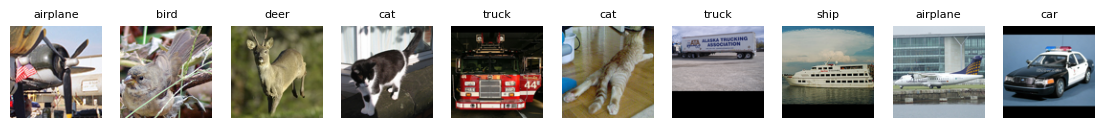

In [11]:
def denorm_stl(x: torch.Tensor) -> torch.Tensor:
    # x: (C,H,W), нормализованный
    mean = torch.tensor(STL10_MEAN).view(3, 1, 1)
    std = torch.tensor(STL10_STD).view(3, 1, 1)
    return x * std + mean

@torch.no_grad()
def show_images(loader, n: int = 10) -> None:
    x, y = next(iter(loader))
    x = x[:n].cpu()
    y = y[:n].cpu()

    plt.figure(figsize=(14, 2))
    for i in range(n):
        plt.subplot(1, n, i + 1)
        img = denorm_stl(x[i]).clamp(0, 1).permute(1, 2, 0).numpy()
        plt.imshow(img)
        plt.title(class_names_A[y[i].item()], fontsize=8)
        plt.axis("off")
    plt.show()

show_images(train_loader_A, n=10)

### Часть B (S11): датасет для детекции или сегментации

In [12]:
@dataclass
class RunConfig:
    data_dir: str = "./data"
    fast_mode: bool = True
    n_show: int = 3
    person_only: bool = True  # мы считаем IoU только по классу "person"

cfg = RunConfig()
cfg

RunConfig(data_dir='./data', fast_mode=True, n_show=3, person_only=True)

In [13]:
# Трансформации для изображений
img_transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize((0.5, 0.5, 0.5), (0.5, 0.5, 0.5)),
])

# Трансформации для масок
mask_transform = transforms.Compose([
    transforms.Resize((224, 224), interpolation=transforms.InterpolationMode.NEAREST),
    transforms.ToTensor(),
])

# Загрузка обучающей части
dataset_v = torchvision.datasets.OxfordIIITPet(
    root='./data',
    split='trainval',       # trainval = train + val (7390 изображений)
    target_types='segmentation', # параметр для загрузки масок
    download=True,         
    transform=img_transform,
    target_transform=mask_transform,
)

# Загрузка тестовой части
test_dataset_v = torchvision.datasets.OxfordIIITPet(
    root='./data',
    split='test',           # test set (3669 изображений)
    target_types='segmentation', # параметр для загрузки масок
    download=True,
    transform=img_transform,
    target_transform=mask_transform,
)

print(f"Train dataset size: {len(dataset_v)}")
print(f"Test dataset size: {len(test_dataset_v)}")

img, mask = dataset_v[0]
print(f"Image shape: {img.shape}")  # [3, 224, 224]
print(f"Mask shape: {mask.shape}")  # [1, 224, 224]

100.0%
100.0%


Train dataset size: 3680
Test dataset size: 3669
Image shape: torch.Size([3, 224, 224])
Mask shape: torch.Size([1, 224, 224])


In [115]:
weights = DeepLabV3_ResNet50_Weights.COCO_WITH_VOC_LABELS_V1
model = deeplabv3_resnet50(weights=weights)
model.to(DEVICE)
model.eval()

categories = weights.meta["categories"]
print("Доступные классы:", categories[:10], "..." if len(categories) > 10 else "")

CAT_IDX = categories.index("cat")
DOG_IDX = categories.index("dog")
PET_IDX = min(CAT_IDX, DOG_IDX)  # Используем первый из них для унификации
PET_CLASSES = [CAT_IDX, DOG_IDX]
print("num_classes:", len(categories))
print("CAT_IDX:", CAT_IDX)
print("DOG_IDX:", DOG_IDX)
print("PET_IDX (используемый):", PET_IDX)

# Трансформации, соответствующие весам
preprocess = weights.transforms()
preprocess

Доступные классы: ['__background__', 'aeroplane', 'bicycle', 'bird', 'boat', 'bottle', 'bus', 'car', 'cat', 'chair'] ...
num_classes: 21
CAT_IDX: 8
DOG_IDX: 12
PET_IDX (используемый): 8


SemanticSegmentation(
    resize_size=[520]
    mean=[0.485, 0.456, 0.406]
    std=[0.229, 0.224, 0.225]
    interpolation=InterpolationMode.BILINEAR
)

### Базовые функции обучения и оценки

In [21]:
def train_one_epoch(model, loader, optimizer, criterion):
    model.train()
    total_loss, total_correct, total_seen = 0.0, 0, 0

    for x, y in loader:
        x, y = x.to(DEVICE), y.to(DEVICE)

        optimizer.zero_grad(set_to_none=True)
        logits = model(x)
        loss = criterion(logits, y)

        if not torch.isfinite(loss):
            return float("nan"), float("nan")

        loss.backward()
        optimizer.step()

        bs = y.size(0)
        total_loss += loss.item() * bs
        total_correct += (torch.argmax(logits, dim=1) == y).sum().item()
        total_seen += bs

    return total_loss / total_seen, total_correct / total_seen

@torch.no_grad()
def evaluate(model, loader, criterion):
    model.eval()
    total_loss, total_correct, total_seen = 0.0, 0, 0

    for x, y in loader:
        x, y = x.to(DEVICE), y.to(DEVICE)
        logits = model(x)
        loss = criterion(logits, y)

        if not torch.isfinite(loss):
            return float("nan"), float("nan")

        bs = y.size(0)
        total_loss += loss.item() * bs
        total_correct += (torch.argmax(logits, dim=1) == y).sum().item()
        total_seen += bs

    return total_loss / total_seen, total_correct / total_seen

def get_lr(optimizer) -> float:
    return float(optimizer.param_groups[0]["lr"])

def fit(model, train_loader, val_loader, optimizer, criterion, epochs: int = 5, verbose: bool = True):
    history = {"train_loss": [], "train_acc": [], "val_loss": [], "val_acc": [], "lr": []}

    for epoch in range(1, epochs + 1):
        t0 = time.time()
        tr_loss, tr_acc = train_one_epoch(model, train_loader, optimizer, criterion)
        va_loss, va_acc = evaluate(model, val_loader, criterion)

        history["train_loss"].append(tr_loss)
        history["train_acc"].append(tr_acc)
        history["val_loss"].append(va_loss)
        history["val_acc"].append(va_acc)
        history["lr"].append(get_lr(optimizer))

        dt = time.time() - t0
        if verbose:
            print(
                f"Epoch {epoch:02d}/{epochs} | "
                f"lr {get_lr(optimizer):.2e} | "
                f"train loss {tr_loss:.4f}, acc {tr_acc:.3f} | "
                f"val loss {va_loss:.4f}, acc {va_acc:.3f} | {dt:.1f}s"
            )

        if (not math.isfinite(tr_loss)) or (not math.isfinite(va_loss)):
            print("NaN/Inf в loss – останавливаем обучение.")
            break

    return history

def plot_history(hist: Dict[str, List[float]], title: str = "") -> None:
    epochs = list(range(1, len(hist["train_loss"]) + 1))

    plt.figure(figsize=(10, 4))
    plt.plot(epochs, hist["train_loss"], label="train loss")
    plt.plot(epochs, hist["val_loss"], label="val loss")
    plt.xlabel("epoch")
    plt.ylabel("loss")
    plt.title(title + " | loss")
    plt.grid(True)
    plt.legend()
    plt.show()

    plt.figure(figsize=(10, 4))
    plt.plot(epochs, hist["train_acc"], label="train acc")
    plt.plot(epochs, hist["val_acc"], label="val acc")
    plt.xlabel("epoch")
    plt.ylabel("accuracy")
    plt.title(title + " | accuracy")
    plt.grid(True)
    plt.legend()
    plt.show()

    plt.figure(figsize=(10, 3))
    plt.plot(epochs, hist["lr"], label="lr")
    plt.xlabel("epoch")
    plt.ylabel("lr")
    plt.title(title + " | lr")
    plt.grid(True)
    plt.legend()
    plt.show()

In [23]:
@torch.no_grad()
def predict_pet_mask(img_pil: Image.Image) -> tuple[torch.Tensor, tuple[int, int]]:
    x = preprocess(img_pil).unsqueeze(0).to(DEVICE)  # [1,3,H,W]
    out = model_B(x)["out"][0]  # [C,H,W]
    pred = out.argmax(0)      # [H,W]
    pet_mask = (pred == int(PET_IDX)).to(torch.uint8)  # питомец вместо человека
    return pet_mask.cpu(), x.shape[-2:]  # (mask, (H,W))

def iou_binary(pred: torch.Tensor, gt: torch.Tensor) -> float:
    pred = pred.bool()
    gt = gt.bool()
    inter = (pred & gt).sum().item()
    union = (pred | gt).sum().item()
    return float(inter / (union + 1e-9))

@torch.no_grad()
def eval_subset(indices: List[int], threshold=0.5 ) -> Dict[str, float]:
    ious = []
    for idx in indices:
        img_pil, gt_np = dataset[idx]
        
        # Предсказание
        pred_mask, (h, w) = predict_pet_mask(img_pil, confidence_threshold = threshold)
        
        # FIX: Конвертируем тензор в numpy и исправляем форму
        if isinstance(gt_np, torch.Tensor):
            gt_np = gt_np.numpy()
        
        # gt_np имеет форму (1, H, W) - нужно (H, W) для PIL
        if gt_np.ndim == 3 and gt_np.shape[0] == 1:
            gt_np = gt_np[0]  # Убираем размерность канала
        
        # Теперь gt_np имеет форму (H, W)
        gt_pil = Image.fromarray((gt_np * 255).astype(np.uint8))
        gt_rs = F.resize(gt_pil, size=[h, w], interpolation=InterpolationMode.NEAREST)
        gt_mask = (torch.from_numpy(np.array(gt_rs)) > 0).to(torch.uint8)
        
        ious.append(iou_binary(pred_mask, gt_mask))
    
    return {
        "n": float(len(ious)),
        "mean_IoU": float(np.mean(ious)),
        "median_IoU": float(np.median(ious)),
        "min_IoU": float(np.min(ious)),
        "max_IoU": float(np.max(ious)),
    }

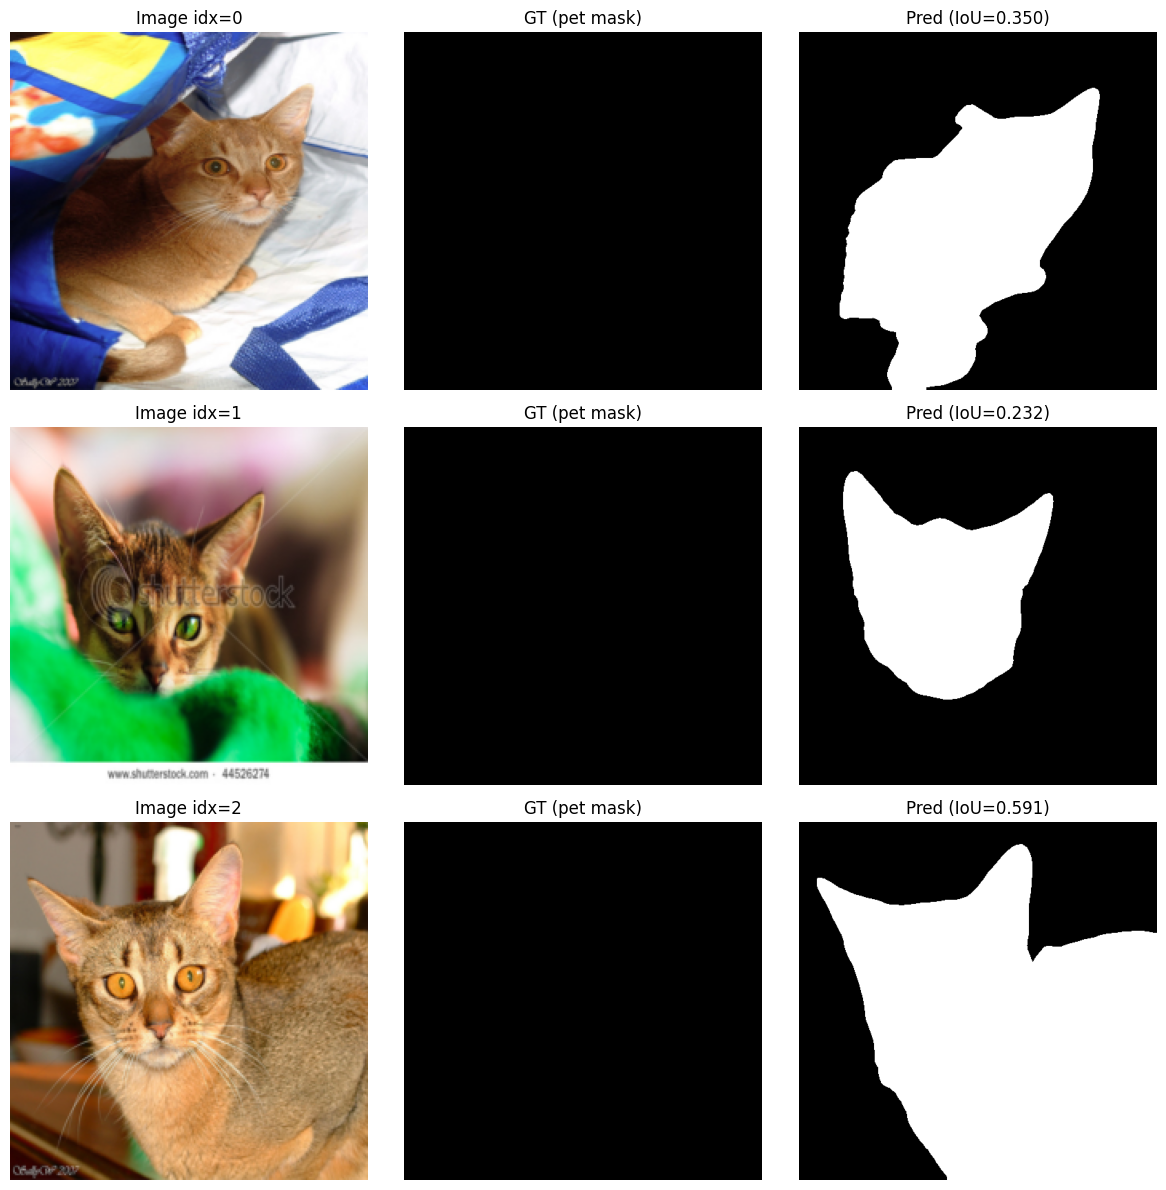

In [45]:
# визуализация предсказаний модели на нескольких примерах
eval_indices = list(range(len(dataset_v)))
visual_indices = eval_indices[:3]

n = min(len(visual_indices), len(dataset_v))
fig, axes = plt.subplots(n, 3, figsize=(12, 4*n))

if n == 1:
    axes = np.expand_dims(axes, axis=0)

for row, idx in enumerate(visual_indices):
    img_tensor, gt_np = dataset_v[idx]
        
    # ========== Конвертация изображения для отображения ==========
    if isinstance(img_tensor, torch.Tensor):
        img_np = img_tensor.permute(1, 2, 0).cpu().numpy()
        img_np = img_np * 0.5 + 0.5  # Denormalize
        img_np = np.clip(img_np, 0, 1)
        img_pil = Image.fromarray((img_np * 255).astype(np.uint8))
    else:
        img_pil = img_tensor
    pred_mask, (h, w) = predict_pet_mask(img_pil)  # pet вместо person

    if isinstance(gt_np, torch.Tensor):
        gt_np = gt_np.cpu().numpy()
    if gt_np.ndim == 3 and gt_np.shape[0] == 1:
        gt_np = gt_np.squeeze(0)
        
    # GT resize to model space
    gt_pil = Image.fromarray((gt_np * 255).astype(np.uint8))
    gt_rs = resize(gt_pil, size=[h, w], interpolation=InterpolationMode.NEAREST)
    gt_mask = (torch.from_numpy(np.array(gt_rs)) > 0).to(torch.uint8)

    iou = iou_binary(pred_mask, gt_mask)

    gt_binary = (gt_np > 1.5/255).astype(np.float32)
    axes[row, 0].imshow(img_pil)
    axes[row, 0].set_title(f"Image idx={idx}")
    axes[row, 0].axis("off")

    axes[row, 1].imshow(gt_mask.numpy(), cmap="gray")
    axes[row, 1].set_title("GT (pet mask)")  # pet вместо person
    axes[row, 1].axis("off")

    axes[row, 2].imshow(pred_mask.numpy(), cmap="gray")
    axes[row, 2].set_title(f"Pred (IoU={iou:.3f})")
    axes[row, 2].axis("off")

plt.tight_layout()
plt.show()


In [47]:
def log_experiment(
    experiment_id: str,
    task: str,
    dataset: str,
    seed: int,
    model_summary: str,
    optimizer: str,
    lr: float,
    epochs_trained: int,
    best_val_accuracy: float = None,
    test_accuracy: float = None,
    precision: float = None,
    recall: float = None,
    mean_iou: float = None,
    notes: str = ""
):
    """
    Минимальная функция логирования экспериментов в runs.csv
    """
    experiment_data = {
        'experiment_id': experiment_id,
        'task': task,
        'dataset': dataset,
        'seed': seed,
        'model_summary': model_summary,
        'optimizer': optimizer,
        'lr': lr,
        'epochs_trained': epochs_trained,
        'best_val_accuracy': best_val_accuracy,
        'test_accuracy': test_accuracy,
        'precision': precision,
        'recall': recall,
        'mean_iou': mean_iou,
        'notes': notes
    }
    
    runs_file = 'artifacts/runs.csv'
    if os.path.exists(runs_file):
        df_existing = pd.read_csv(runs_file)
        df_new = pd.DataFrame([experiment_data])
        df_final = pd.concat([df_existing, df_new], ignore_index=True)
    else:
        df_final = pd.DataFrame([experiment_data])
    
    # Сохраняем
    df_final.to_csv(runs_file, index=False)
    print(f"[{experiment_id}] Сохранено в runs.csv")
    
    return df_final

## Эксперименты

### Часть A (S10): классификация, аугментации и transfer learning

In [48]:
stl10_full = torchvision.datasets.STL10('./data', split='train', download=True)
train_size = int(0.8 * len(stl10_full))
val_size = len(stl10_full) - train_size
train_idx, val_idx = torch.utils.data.random_split(range(len(stl10_full)), [train_size, val_size], 
                                                  generator=torch.Generator())

#### C1 (simple-cnn-base): простая CNN без аугментаций

In [49]:
stl10_train_C1 = torchvision.datasets.STL10(DATA_DIR, split='train', transform=basic_transform, download=True)
train_size_C1 = int(0.8 * len(stl10_train_C1))
val_size_C1 = len(stl10_train_C1) - train_size
stl10_train_C1, stl10_val_C1 = random_split(stl10_train_C1, [train_size_C1, val_size_C1], generator=torch.Generator())

train_loader_C1 = DataLoader(stl10_train_C1, BATCH_SIZE, shuffle=True)
val_loader_C1 = DataLoader(stl10_val_C1, BATCH_SIZE, shuffle=False)
test_loader_C1 = DataLoader(torchvision.datasets.STL10('./data', split='test', transform=basic_transform), BATCH_SIZE)

# Простая CNN
class SimpleCNN(nn.Module):
    def __init__(self, num_classes=10):
        super().__init__()
        self.features = nn.Sequential(
            nn.Conv2d(3, 32, 3, padding=1), nn.ReLU(), nn.MaxPool2d(2,2),
            nn.Conv2d(32, 64, 3, padding=1), nn.ReLU(), nn.MaxPool2d(2,2),
            nn.Conv2d(64, 128, 3, padding=1), nn.ReLU(), nn.MaxPool2d(2,2),
        )
        self.classifier = nn.Sequential(
            nn.Linear(128 * 12 * 12, 512), nn.ReLU(), nn.Dropout(0.5),
            nn.Linear(512, num_classes)
        )
    
    def forward(self, x):
        x = self.features(x)
        x = x.view(x.size(0), -1)
        x = self.classifier(x)
        return x

Epoch 01/5 | lr 1.00e-03 | train loss 1.9525, acc 0.270 | val loss 1.6719, acc 0.381 | 36.1s
Epoch 02/5 | lr 1.00e-03 | train loss 1.5200, acc 0.443 | val loss 1.4427, acc 0.486 | 35.3s
Epoch 03/5 | lr 1.00e-03 | train loss 1.2983, acc 0.516 | val loss 1.2610, acc 0.548 | 35.3s
Epoch 04/5 | lr 1.00e-03 | train loss 1.1337, acc 0.581 | val loss 1.2411, acc 0.551 | 35.4s
Epoch 05/5 | lr 1.00e-03 | train loss 0.9740, acc 0.649 | val loss 1.2452, acc 0.565 | 35.9s


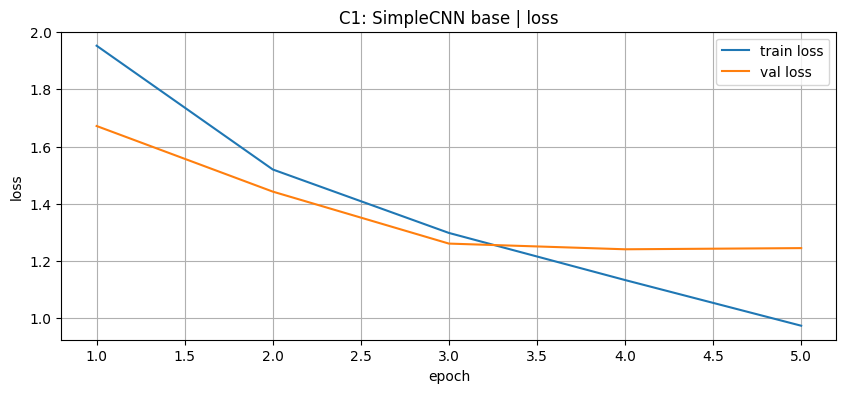

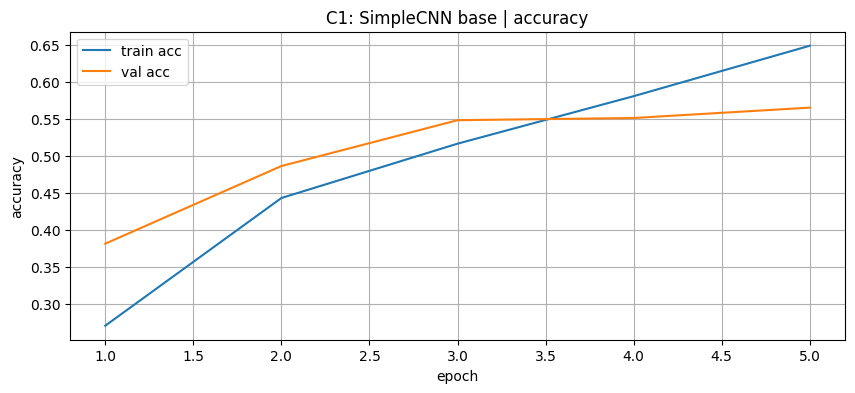

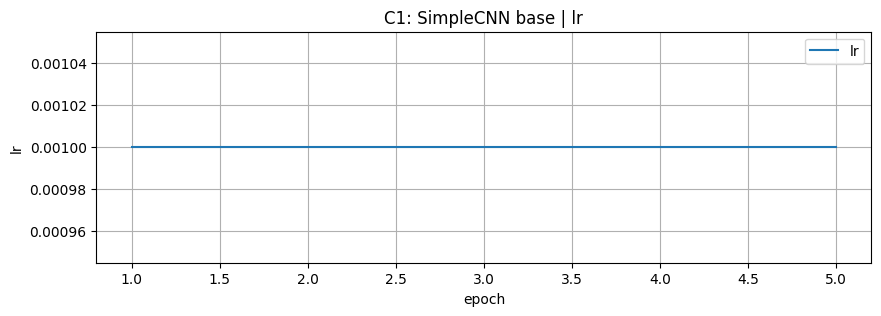

In [51]:
model_c1 = SimpleCNN().to(DEVICE)
criterion = nn.CrossEntropyLoss()
optimizer_c1 = torch.optim.Adam(model_c1.parameters(), lr=0.001)

history_c1 = fit(model_c1, train_loader_C1, val_loader_C1, optimizer_c1, criterion, epochs=EPOCHS)
best_val_acc_c1 = max(history_c1["val_acc"])

plot_history(history_c1, "C1: SimpleCNN base")

In [52]:
log_experiment(
    experiment_id='C1',
    task='classification',
    dataset='STL10',
    seed=RANDOM_STATE,
    model_summary='SimpleCNN 3conv+2fc',
    optimizer='Adam',
    lr=0.001,
    epochs_trained=len(history_c1["val_acc"]),
    best_val_accuracy=best_val_acc_c1,
    test_accuracy=None,
    notes='простая CNN без аугментаций'
)

[C1] Сохранено в runs.csv


,experiment_id,task,dataset,seed,model_summary,optimizer,lr,epochs_trained,best_val_accuracy,test_accuracy,precision,recall,mean_iou,notes
0,C1,classification,STL10,19,SimpleCNN 3conv+2fc,Adam,0.001,5,0.565,None,None,None,None,простая CNN без аугментаций


#### C2 (simple-cnn-aug): та же CNN, но с разумными аугментациями.

In [53]:
dataset_c2_train = torchvision.datasets.STL10(DATA_DIR, split='train', transform=train_transform)
dataset_c2_val = torchvision.datasets.STL10(DATA_DIR, split='train', transform=train_transform)
train_loader_c2 = DataLoader(torch.utils.data.Subset(dataset_c2_train, train_idx), 64, shuffle=True)
val_loader_c2 = DataLoader(torch.utils.data.Subset(dataset_c2_val, val_idx), 64, shuffle=False)

Epoch 01/5 | lr 1.00e-03 | train loss 2.0562, acc 0.226 | val loss 1.7380, acc 0.311 | 39.0s
Epoch 02/5 | lr 1.00e-03 | train loss 1.6944, acc 0.343 | val loss 1.5960, acc 0.403 | 38.8s
Epoch 03/5 | lr 1.00e-03 | train loss 1.5756, acc 0.397 | val loss 1.5806, acc 0.417 | 38.8s
Epoch 04/5 | lr 1.00e-03 | train loss 1.5082, acc 0.424 | val loss 1.4984, acc 0.435 | 38.0s
Epoch 05/5 | lr 1.00e-03 | train loss 1.4754, acc 0.432 | val loss 1.4495, acc 0.486 | 39.2s


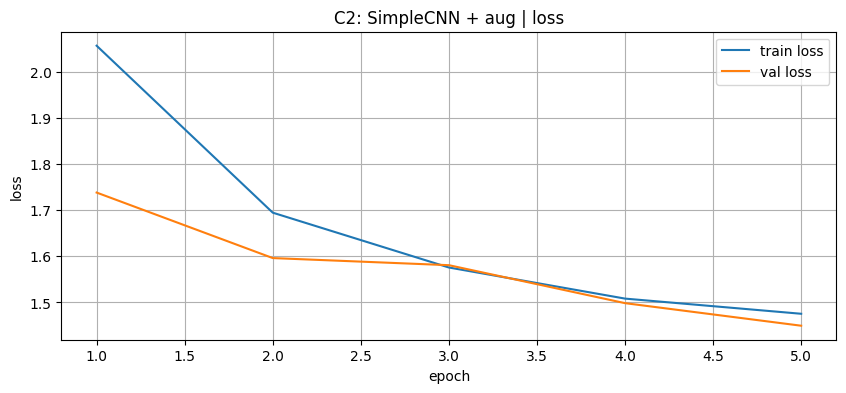

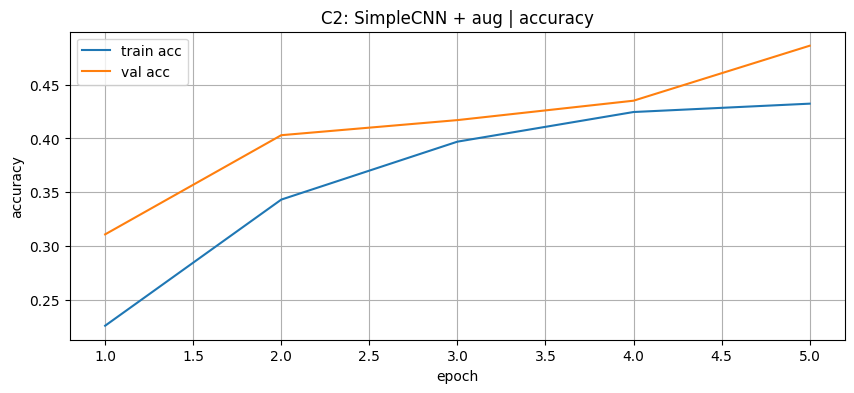

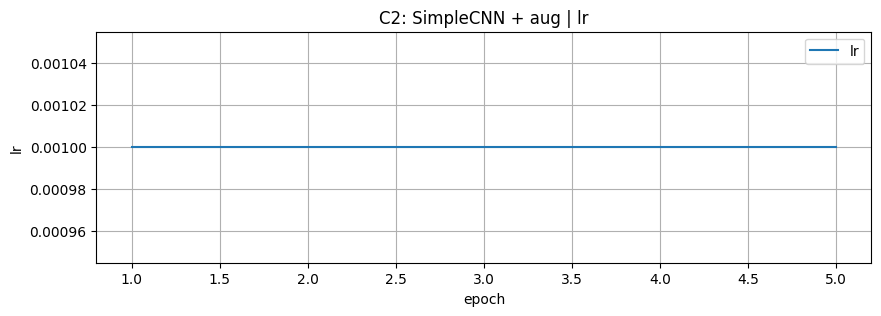

In [54]:
model_c2 = SimpleCNN().to(DEVICE)
optimizer_c2 = torch.optim.Adam(model_c2.parameters(), lr=0.001)

history_c2 = fit(model_c2, train_loader_c2, val_loader_c2, optimizer_c2, criterion, epochs=EPOCHS)
best_val_acc_c2 = max(history_c2["val_acc"])

plot_history(history_c2, "C2: SimpleCNN + aug")

In [55]:
log_experiment(
    experiment_id='C2',
    task='classification',
    dataset='STL10',
    seed=RANDOM_STATE,
    model_summary='SimpleCNN 3conv+2fc',
    optimizer='Adam',
    lr=0.001,
    epochs_trained=len(history_c2["val_acc"]),
    best_val_accuracy=best_val_acc_c2,
    test_accuracy=None,
    notes='та же CNN, но с разумными аугментациями'
)

[C2] Сохранено в runs.csv


,experiment_id,task,dataset,seed,model_summary,optimizer,lr,epochs_trained,best_val_accuracy,test_accuracy,precision,recall,mean_iou,notes
0,C1,classification,STL10,19,SimpleCNN 3conv+2fc,Adam,0.001,5,0.565,NaN,NaN,NaN,NaN,простая CNN без аугментаций
1,C2,classification,STL10,19,SimpleCNN 3conv+2fc,Adam,0.001,5,0.486,None,None,None,None,"та же CNN, но с разумными аугментациями"


#### C3 (resnet18-head-only)

In [56]:
def get_resnet18_weights():
    try:
        w = ResNet18_Weights.DEFAULT
        return w
    except Exception as e:
        print("Не удалось получить веса ResNet18_Weights.DEFAULT. Причина:", repr(e))
        return None

weights = get_resnet18_weights()
print("weights:", weights)

def count_trainable_params(model: nn.Module) -> int:
    return sum(p.numel() for p in model.parameters() if p.requires_grad)

def build_resnet18(num_classes: int = 10, weights=weights) -> nn.Module:
    # Внимание: реальная загрузка весов может требовать интернет.
    # Если не получается – используйте weights=None.
    try:
        model = resnet18(weights=weights)
    except Exception as e:
        print("Не удалось загрузить предобученные веса. Переходим на weights=None. Причина:", repr(e))
        model = resnet18(weights=None)

    model.fc = nn.Linear(model.fc.in_features, num_classes)
    return model

def set_requires_grad(module: nn.Module, flag: bool) -> None:
    for p in module.parameters():
        p.requires_grad = flag

model = build_resnet18(num_classes=10, weights=weights).to(DEVICE)
print(model)
print("Trainable params:", count_trainable_params(model))

weights: ResNet18_Weights.IMAGENET1K_V1
ResNet(
  (conv1): Conv2d(3, 64, kernel_size=(7, 7), stride=(2, 2), padding=(3, 3), bias=False)
  (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (relu): ReLU(inplace=True)
  (maxpool): MaxPool2d(kernel_size=3, stride=2, padding=1, dilation=1, ceil_mode=False)
  (layer1): Sequential(
    (0): BasicBlock(
      (conv1): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (relu): ReLU(inplace=True)
      (conv2): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn2): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    )
    (1): BasicBlock(
      (conv1): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=T

In [57]:
dataset_c3_train = torchvision.datasets.STL10(DATA_DIR, split='train', transform=resnet_transform)
dataset_c3_val = torchvision.datasets.STL10(DATA_DIR, split='train', transform=resnet_transform)
train_loader_c3 = DataLoader(torch.utils.data.Subset(dataset_c3_train, train_idx), 64, shuffle=True)
val_loader_c3 = DataLoader(torch.utils.data.Subset(dataset_c3_val, val_idx), 64, shuffle=False)
test_loader_c3 = DataLoader(torchvision.datasets.STL10(DATA_DIR, split='test', transform=resnet_transform), 64)

In [ ]:
def create_head_only_model():
    model = build_resnet18(num_classes=10, weights=weights).to(DEVICE)
    
    # Замораживаем весь backbone
    set_requires_grad(model, False)
    
    # Заменяем FC слой под 10 классов STL10
    model.fc = nn.Linear(model.fc.in_features, NUM_CLASSES)
    
    # Размораживаем только FC слой
    set_requires_grad(model.fc, True)
    
    print("C3 (head-only): Backbone заморожен, обучаются только FC параметры")
    total_params = sum(p.numel() for p in model.parameters())
    trainable_params = sum(p.numel() for p in model.parameters() if p.requires_grad)
    print(f"Total params: {total_params:,}, Trainable: {trainable_params:,}")
    
    return model


Phase 1: head-only training
Epoch 01/3 | lr 1.00e-03 | train loss 1.0624, acc 0.725 | val loss 0.4530, acc 0.914 | 159.6s
Epoch 02/3 | lr 1.00e-03 | train loss 0.3580, acc 0.927 | val loss 0.2740, acc 0.939 | 160.5s
Epoch 03/3 | lr 1.00e-03 | train loss 0.2582, acc 0.935 | val loss 0.2195, acc 0.944 | 163.2s


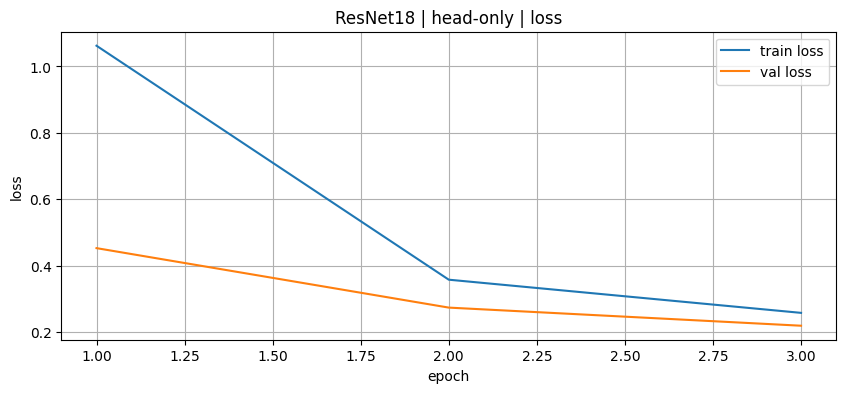

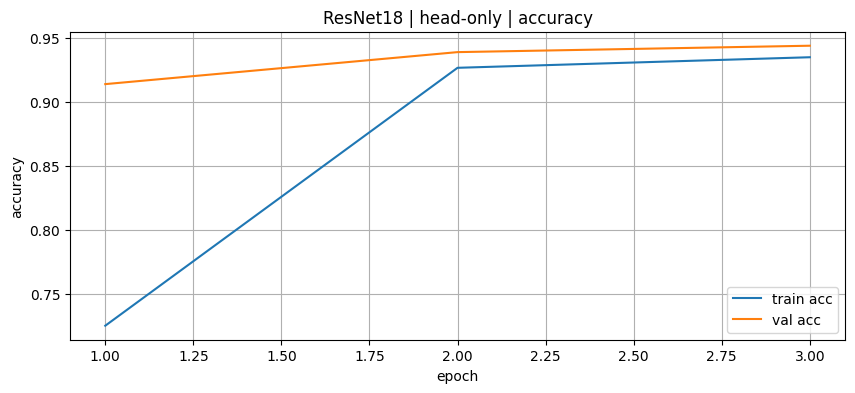

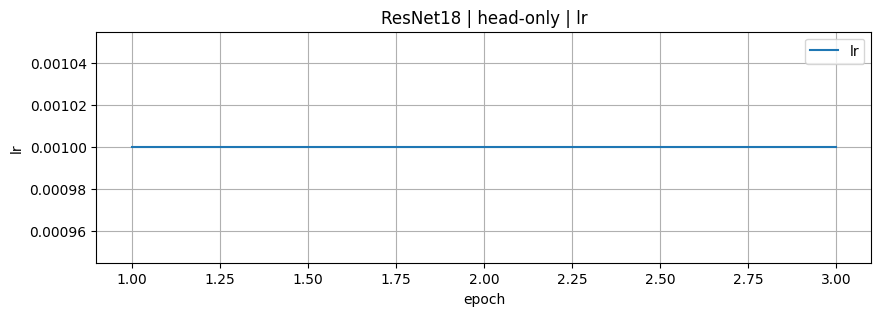

In [59]:
EPOCHS_HEAD = 3 if FAST_MODE else 8
EPOCHS_FT   = 3 if FAST_MODE else 8

criterion_c3 = nn.CrossEntropyLoss()

HEAD_ONLY = True
FREEZE_BACKBONE = True

model_c3 = build_resnet18(num_classes=10, weights=weights).to(DEVICE)
model_с3.fc = nn.Linear(model.fc.in_features, 10)

if FREEZE_BACKBONE:
    set_requires_grad(model_c3, False)
    set_requires_grad(model_c3.fc, True)
else:
    set_requires_grad(model_c3, True)  # разморозить всё

optimizer_c3 = (
    torch.optim.Adam(model_c3.fc.parameters(), lr=0.001)
    if HEAD_ONLY
    else torch.optim.Adam(model_c3.parameters(), lr=1e-4)
)

print("\n" + "=" * 80)
print("Phase 1: head-only training")
hist_c3 = fit(model_c3, train_loader_c3, val_loader_c3, optimizer_c3, criterion_c3, epochs=EPOCHS_HEAD, verbose=True)
plot_history(hist_c3, title="ResNet18 | head-only")

In [60]:
best_val_acc_c3 = max(hist_c3["val_acc"])

log_experiment(
    experiment_id='C3',
    task='classification',
    dataset='STL10',
    seed=RANDOM_STATE,
    model_summary='ResNet18 pretrained, head-only',
    optimizer='Adam',
    lr=0.001,
    epochs_trained=len(hist_c3["val_acc"]),
    best_val_accuracy=best_val_acc_c3,
    test_accuracy=None,
    notes='ResNet18 с pretrained weights; backbone заморожен, обучается только классификационная голова.'
)

[C3] Сохранено в runs.csv


,experiment_id,task,dataset,seed,model_summary,optimizer,lr,epochs_trained,best_val_accuracy,test_accuracy,precision,recall,mean_iou,notes
0,C1,classification,STL10,19,SimpleCNN 3conv+2fc,Adam,0.001,5,0.565,NaN,NaN,NaN,NaN,простая CNN без аугментаций
1,C2,classification,STL10,19,SimpleCNN 3conv+2fc,Adam,0.001,5,0.486,NaN,NaN,NaN,NaN,"та же CNN, но с разумными аугментациями"
2,C3,classification,STL10,19,"ResNet18 pretrained, head-only",Adam,0.001,3,0.944,None,None,None,None,ResNet18 с pretrained weights; backbone заморо...


#### C4 (resnet18-finetune)

Trainable params (layer4+fc): 5130

Phase 2: fine-tuning layer4 + fc
Epoch 01/3 | lr 1.00e-03 | train loss 0.2164, acc 0.939 | val loss 0.1893, acc 0.947 | 163.0s
Epoch 02/3 | lr 1.00e-03 | train loss 0.1704, acc 0.956 | val loss 0.1775, acc 0.942 | 164.1s
Epoch 03/3 | lr 1.00e-03 | train loss 0.1520, acc 0.956 | val loss 0.1608, acc 0.950 | 170.5s


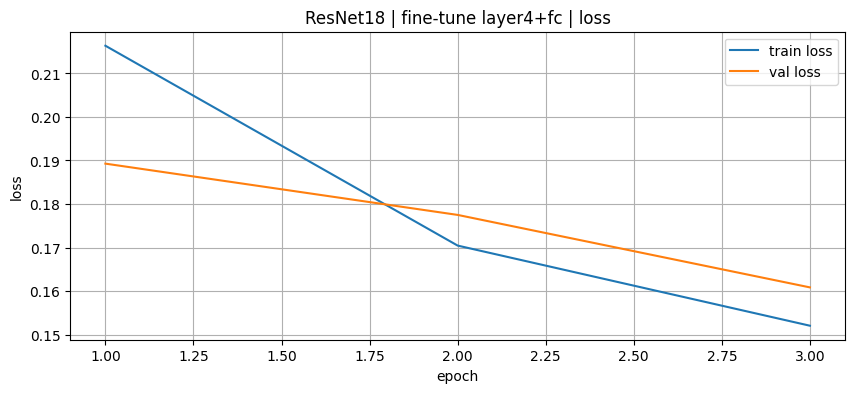

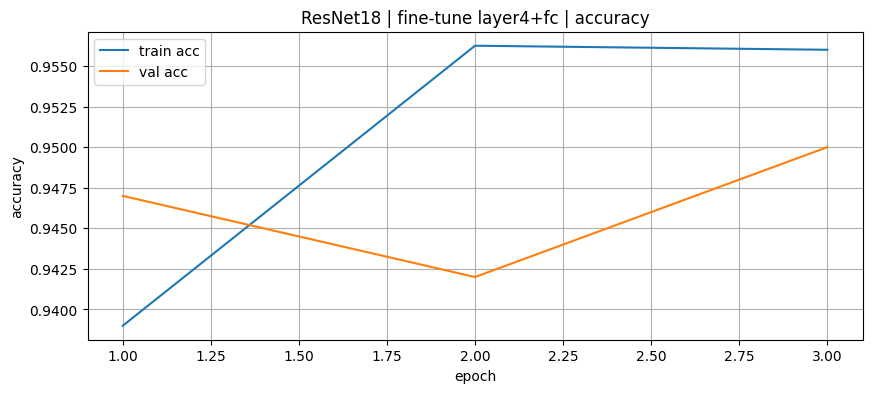

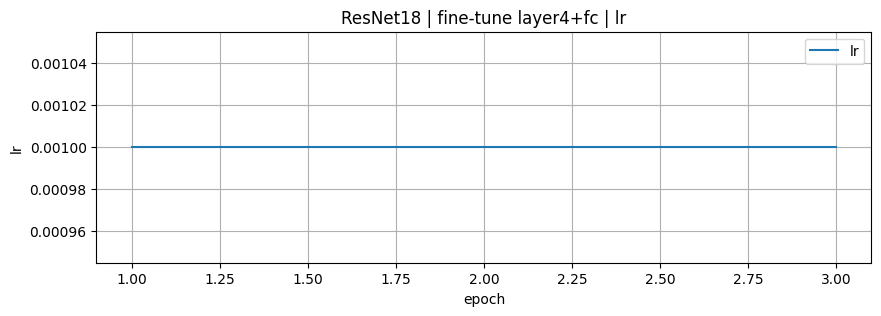

In [66]:
HEAD_ONLY = True
FREEZE_BACKBONE = True

if FREEZE_BACKBONE:
    set_requires_grad(model_c3, False)
    set_requires_grad(model_c3.fc, True)
else:
    set_requires_grad(model_head.layer4, True)
    set_requires_grad(model_head.fc, True)

print("Trainable params (layer4+fc):", count_trainable_params(model_c3))

# param groups: backbone меньше, head больше
params = [
    {"params": model_c3.layer4.parameters(), "lr": 1e-4},
    {"params": model_c3.fc.parameters(), "lr": 1e-3},
]

optimizer_c4 = (
    torch.optim.Adam(model_c3.fc.parameters(), lr=0.001)
    if HEAD_ONLY
    else torch.optim.Adam(model_c3.parameters(), lr=1e-4)
)

print("\n" + "=" * 80)
print("Phase 2: fine-tuning layer4 + fc")
hist_с4 = fit(model_c3, train_loader_c3, val_loader_c3, optimizer_c4, criterion, epochs=EPOCHS_FT, verbose=True)
plot_history(hist_с4, title="ResNet18 | fine-tune layer4+fc")

In [67]:
best_val_acc_c4 = max(hist_с4["val_acc"])

По оценке val_accuracy наилучшей моделью является С4

In [71]:
test_loss_c4, test_acc_c4 = evaluate(model_c3, test_loader_c3, criterion)

In [73]:
# Логируем C4
log_experiment(
    experiment_id='C4',
    task='classification',
    dataset='STL10',
    seed=RANDOM_STATE,
    model_summary='ResNet18 pretrained, layer4+fc',
    optimizer='Adam',
    lr=0.0001,
    epochs_trained=len(hist_с4["val_acc"]),
    best_val_accuracy=best_val_acc_c4,
    test_accuracy=test_acc_c4,
    notes='ResNet18 с pretrained weights; частичное fine-tune (например, layer4 + fc, либо другой близкий по смыслу вариант).'
)

[C4] Сохранено в runs.csv


,experiment_id,task,dataset,seed,model_summary,optimizer,lr,epochs_trained,best_val_accuracy,test_accuracy,precision,recall,mean_iou,notes
0,C1,classification,STL10,19,SimpleCNN 3conv+2fc,Adam,0.0010,5,0.565,NaN,NaN,NaN,NaN,простая CNN без аугментаций
1,C2,classification,STL10,19,SimpleCNN 3conv+2fc,Adam,0.0010,5,0.486,NaN,NaN,NaN,NaN,"та же CNN, но с разумными аугментациями"
2,C3,classification,STL10,19,"ResNet18 pretrained, head-only",Adam,0.0010,3,0.944,NaN,NaN,NaN,NaN,ResNet18 с pretrained weights; backbone заморо...
3,C4,classification,STL10,19,"ResNet18 pretrained, layer4+fc",Adam,0.0001,3,0.950,0.94075,None,None,None,ResNet18 с pretrained weights; частичное fine-...


In [75]:
best_epoch_ft = np.argmax(hist_с4["val_acc"])
torch.save({
    'model_state_dict': model_c3.state_dict(),
    'best_val_acc': best_val_acc_c4,
    'best_epoch': best_epoch_ft,
    'test_acc': test_acc_c4,
}, 'artifacts/best_classifier.pt')
print("Сохранено best_classifier.pt")

Сохранено best_classifier.pt


In [76]:
best_config = {
    # Основные параметры
    "dataset": "STL10",
    "task": "classification", 
    "num_classes": 10,
    "architecture": "ResNet18",
    "pretrained": "IMAGENET" if weights else "None",
    
    # Обучение head-only
    "head_only_epochs": EPOCHS_HEAD,
    "head_optimizer": "Adam",
    "head_lr": 0.001,
    
    # Fine-tune
    "finetune_layers": "layer4+fc",
    "finetune_epochs": EPOCHS_FT,
    "finetune_optimizer": "Adam",
    "finetune_lr_layer4": 1e-4,
    "finetune_lr_fc": 1e-3,
    "weight_decay": 1e-4,
    
    # Метрики лучшей модели
    "best_val_accuracy": float(best_val_acc_c4),
    "test_accuracy": float(test_acc_c4),
    "best_epoch": int(best_epoch_ft),
    
    # Воспроизводимость
    "seed": int(RANDOM_STATE),
    "device": str(DEVICE),
    
    "batch_size": 64,
    "transforms": "resnet_transform",  # предполагается стандартный STL10 transform
}

# Сохранение плоского JSON конфига
with open('artifacts/best_classifier_config.json', 'w') as f:
    json.dump(best_config, f, indent=2)


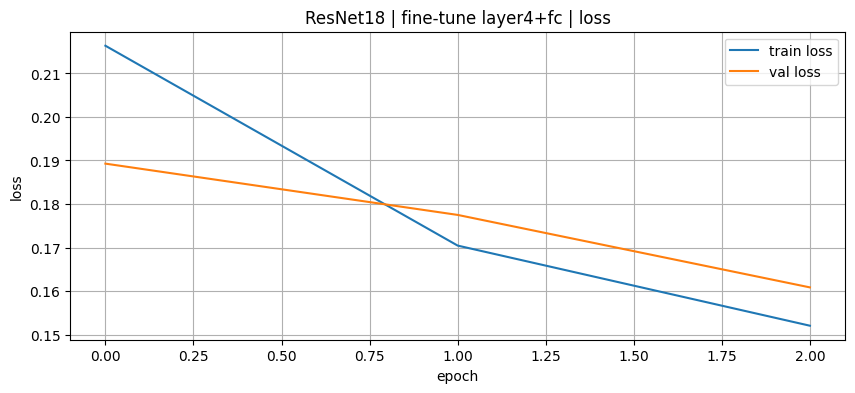

In [78]:
plt.figure(figsize=(10, 4))
plt.plot(hist_с4["train_loss"], label="train loss")
plt.plot(hist_с4["val_loss"], label="val loss")
plt.xlabel("epoch")
plt.ylabel("loss")
plt.title("ResNet18 | fine-tune layer4+fc | loss")
plt.grid(True)
plt.legend()
plt.savefig('artifacts/figures/classification_curves_best.png')

### 

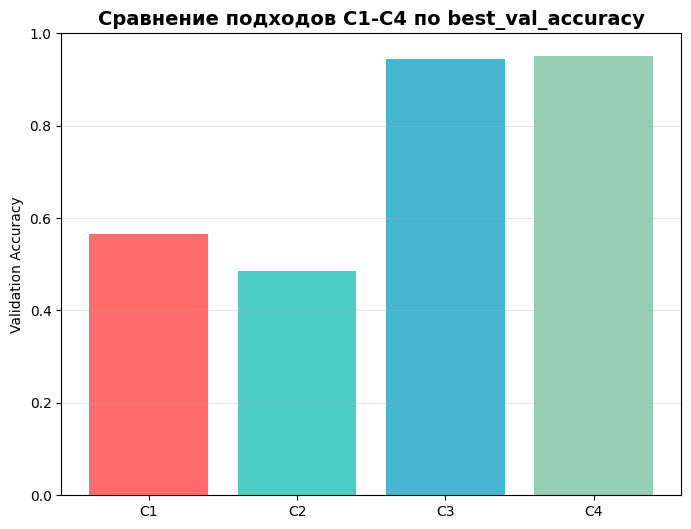

In [79]:
fig, ax = plt.subplots(1, 1, figsize=(8, 6))
models = ['C1', 'C2', 'C3', 'C4']
accuracies = [best_val_acc_c1, best_val_acc_c2, best_val_acc_c3, best_val_acc_c4]
colors = ['#FF6B6B', '#4ECDC4', '#45B7D1', '#96CEB4']

bars = ax.bar(models, accuracies, color=colors)
ax.set_title('Сравнение подходов C1-C4 по best_val_accuracy', fontsize=14, fontweight='bold')
ax.set_ylabel('Validation Accuracy')
ax.set_ylim(0, 1)

plt.grid(True, alpha=0.3, axis='y')
plt.savefig('artifacts/figures/classification_compare.png')

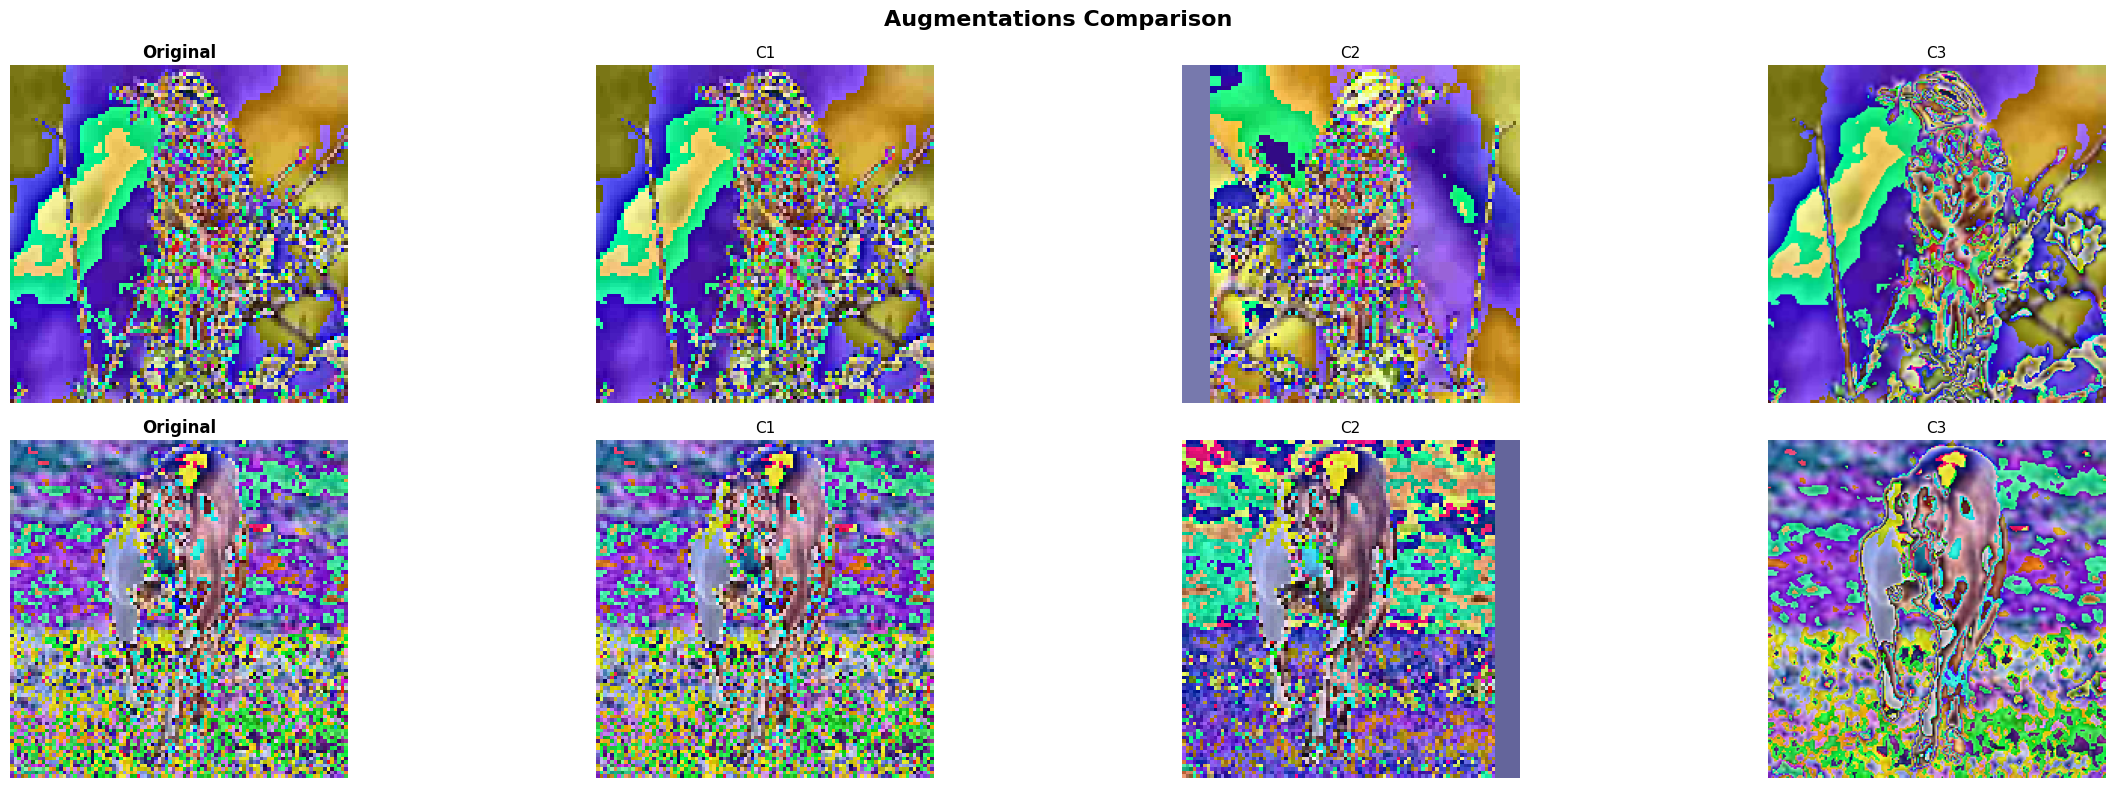

In [80]:
fig, axes = plt.subplots(2, 4, figsize=(25, 4*2))
    
datasets = {
    'C1 (basic)': stl10_train_C1.dataset if hasattr(stl10_train_C1, 'dataset') else stl10_train_C1,
    'C2 (train)': dataset_c2_train,
    'C3 (subset)': dataset_c3_train, 
    }
    
transforms = {
    'C1 (basic)': basic_transform,
    'C2 (train)': train_transform,
    'C3 (subset)': resnet_transform,
}
    
for row in range(2):
    img_idx = row  # берем последовательные изображения
        
    # Колонка 0: Original (без трансформаций)
    orig_img, _ = datasets['C1 (basic)'][img_idx] if hasattr(datasets['C1 (basic)'], '__getitem__') else datasets['C1 (basic)'][img_idx]
    if isinstance(orig_img, torch.Tensor):
        orig_img = F.to_pil_image(orig_img)
    axes[row, 0].imshow(orig_img)
    axes[row, 0].set_title('Original', fontsize=12, fontweight='bold')
    axes[row, 0].axis('off')
        
    # Колонки 1-4: трансформации C1-C4
    for col, (name, dataset) in enumerate(datasets.items(), 1):
        try:
            img_pil, _ = dataset[img_idx]
            if isinstance(img_pil, torch.Tensor):
                img_pil = F.to_pil_image(img_pil)
            axes[row, col].imshow(img_pil)
            axes[row, col].set_title(name.split()[0], fontsize=11)
            axes[row, col].axis('off')
        except:
            axes[row, col].text(0.5, 0.5, 'N/A', ha='center', va='center', transform=axes[row, col].transAxes)
            axes[row, col].set_title(name.split()[0], fontsize=11)
            axes[row, col].axis('off')
    
plt.suptitle('Augmentations Comparison', fontsize=16, fontweight='bold', y=0.98)
plt.tight_layout()
plt.savefig('artifacts/figures/augmentations_preview.png')

#### V1: базовая постобработка маски

In [116]:
weights = DeepLabV3_ResNet50_Weights.COCO_WITH_VOC_LABELS_V1
model = deeplabv3_resnet50(weights=weights)
model.to(DEVICE)
model.eval()

categories = weights.meta["categories"]
print("Доступные классы:", categories[:10], "..." if len(categories) > 10 else "")

CAT_IDX = categories.index("cat")
DOG_IDX = categories.index("dog")
PET_IDX = min(CAT_IDX, DOG_IDX)  # Используем первый из них для унификации
PET_CLASSES = [CAT_IDX, DOG_IDX]
print("num_classes:", len(categories))
print("CAT_IDX:", CAT_IDX)
print("DOG_IDX:", DOG_IDX)
print("PET_IDX (используемый):", PET_IDX)

# Трансформации, соответствующие весам
preprocess = weights.transforms()
preprocess

Доступные классы: ['__background__', 'aeroplane', 'bicycle', 'bird', 'boat', 'bottle', 'bus', 'car', 'cat', 'chair'] ...
num_classes: 21
CAT_IDX: 8
DOG_IDX: 12
PET_IDX (используемый): 8


SemanticSegmentation(
    resize_size=[520]
    mean=[0.485, 0.456, 0.406]
    std=[0.229, 0.224, 0.225]
    interpolation=InterpolationMode.BILINEAR
)

In [117]:
@torch.no_grad()
def predict_pet_mask(img_pil: Image.Image, confidence_threshold=0.5):
    x = preprocess(img_pil).unsqueeze(0).to(DEVICE)
    out = model(x)["out"][0]           # [21, H, W]
    probs = torch.softmax(out, dim=0)   # [21, H, W]
    # Суммируем вероятности для классов кошки и собаки
    pet_probs = probs[PET_CLASSES].sum(dim=0)  # [H, W]
    pet_mask = pet_probs > confidence_threshold
    return pet_mask.to(torch.uint8).cpu(), x.shape[-2:]

In [124]:
def iou_binary(pred: torch.Tensor, gt: torch.Tensor) -> float:
    pred = pred.bool()
    gt = gt.bool()
    inter = (pred & gt).sum().item()
    union = (pred | gt).sum().item()
    return float(inter / (union + 1e-9))

@torch.no_grad()
def eval_subset(indices: List[int], version: str = "V1", threshold: float = 0.5) -> Dict[str, float]:
    predict_fn = predict_pet_mask_v1 if version == "V1" else predict_pet_mask_v2
    ious = []
    
    for idx in indices:
        img_pil, gt_np = dataset[idx]
        
        # Гарантировать, что gt_np — numpy‑массив
        if isinstance(gt_np, Image.Image):
            gt_np = np.array(gt_np)
        elif not isinstance(gt_np, np.ndarray):
            gt_np = np.array(gt_np)

        if gt_np.ndim == 0:  # скаляр
            gt_np = gt_np[None, None]  # [1, 1]

        pred_mask, (h, w) = predict_fn(img_pil, threshold=threshold)

        # resize GT to model space
        gt_pil = Image.fromarray((gt_np * 255).astype(np.uint8))
        gt_rs = F.resize(gt_pil, size=[h, w], interpolation=InterpolationMode.NEAREST)
        gt_mask = (torch.from_numpy(np.array(gt_rs)) > 0).to(torch.uint8)

        ious.append(iou_binary(pred_mask, gt_mask))

    return {
        "version": version,
        "threshold": threshold,
        "n": float(len(ious)),
        "mean_IoU": float(np.mean(ious)),
        "median_IoU": float(np.median(ious)),
        "min_IoU": float(np.min(ious)),
        "max_IoU": float(np.max(ious)),
    }

In [125]:
if cfg.fast_mode:
    test_indices = list(range(len(dataset)//100))
else:
    test_indices = list(range(len(dataset)))

metrics_v1 = eval_subset(test_indices)

In [126]:
metrics_v1

{'version': 'V1',
 'threshold': 0.5,
 'n': 50.0,
 'mean_IoU': 0.15218587278106455,
 'median_IoU': 0.06989644970414174,
 'min_IoU': 0.0,
 'max_IoU': 0.6883912721893466}

In [127]:
log_experiment(
    experiment_id="V1",
    task="segmentation",
    dataset="OxfordIIITPet",
    seed=RANDOM_STATE,
    model_summary=f"DeepLabV3_ResNet50 pretrained COCO, PET_IDX={PET_IDX}, threshold=0.5",
    optimizer=None,
    lr=None,
    epochs_trained=0,
    mean_iou=metrics_v1['mean_IoU'],
    notes=f"базовая постобработка маски]"
)

[V1] Сохранено в runs.csv


C:\Users\Polina\AppData\Local\Temp\ipykernel_12872\4261354937.py:41: FutureWarning: The behavior of DataFrame concatenation with empty or all-NA entries is deprecated. In a future version, this will no longer exclude empty or all-NA columns when determining the result dtypes. To retain the old behavior, exclude the relevant entries before the concat operation.
  df_final = pd.concat([df_existing, df_new], ignore_index=True)


,experiment_id,task,dataset,seed,model_summary,optimizer,lr,epochs_trained,best_val_accuracy,test_accuracy,precision,recall,mean_iou,notes
0,C1,classification,STL10,19,SimpleCNN 3conv+2fc,Adam,0.0010,5,0.565,NaN,NaN,NaN,NaN,простая CNN без аугментаций
1,C2,classification,STL10,19,SimpleCNN 3conv+2fc,Adam,0.0010,5,0.486,NaN,NaN,NaN,NaN,"та же CNN, но с разумными аугментациями"
2,C3,classification,STL10,19,"ResNet18 pretrained, head-only",Adam,0.0010,3,0.944,NaN,NaN,NaN,NaN,ResNet18 с pretrained weights; backbone заморо...
3,C4,classification,STL10,19,"ResNet18 pretrained, layer4+fc",Adam,0.0001,3,0.950,0.94075,NaN,NaN,NaN,ResNet18 с pretrained weights; частичное fine-...
4,V1,segmentation,OxfordIIITPet,19,"DeepLabV3_ResNet50 pretrained COCO, PET_IDX=8,...",None,NaN,0,NaN,NaN,NaN,NaN,0.152186,базовая постобработка маски]


#### V2: альтернативная постобработка маски

In [128]:
@torch.no_grad()
def predict_pet_mask_v2(img_pil: Image.Image, threshold: float = 0.1) -> tuple[torch.Tensor, tuple[int, int]]:
    x = preprocess(img_pil).unsqueeze(0).to(DEVICE)
    out = model(x)["out"][0]
    
    pred_class = out.argmax(0)
    pet_mask = (pred_class == int(PET_IDX)).float()
    pet_probs = torch.softmax(out, dim=0)[PET_IDX]
    
    pet_mask = (pet_probs > threshold).to(torch.uint8)
    
    return pet_mask.cpu(), x.shape[-2:]

In [129]:
metrics_v2 = eval_subset(eval_indices, version="V2", threshold=0.2)
metrics_v2

{'version': 'V2',
 'threshold': 0.2,
 'n': 20.0,
 'mean_IoU': 0.1730747041420112,
 'median_IoU': 0.029950073964496934,
 'min_IoU': 0.0,
 'max_IoU': 0.7373853550295831}

In [130]:
log_experiment(
    experiment_id="V2",
    task="segmentation",
    dataset="OxfordIIITPet",
    seed=RANDOM_STATE,
    model_summary=f"DeepLabV3_ResNet50 pretrained COCO, PET_IDX={PET_IDX}, threshold=0.1",
    optimizer=None,
    lr=None,
    epochs_trained=0,
    mean_iou=metrics_v2['mean_IoU'],
    notes=f"альтернативная постобработка маски, другой порог для бинаризации выбранного foreground-класса"
)

[V2] Сохранено в runs.csv


C:\Users\Polina\AppData\Local\Temp\ipykernel_12872\4261354937.py:41: FutureWarning: The behavior of DataFrame concatenation with empty or all-NA entries is deprecated. In a future version, this will no longer exclude empty or all-NA columns when determining the result dtypes. To retain the old behavior, exclude the relevant entries before the concat operation.
  df_final = pd.concat([df_existing, df_new], ignore_index=True)


,experiment_id,task,dataset,seed,model_summary,optimizer,lr,epochs_trained,best_val_accuracy,test_accuracy,precision,recall,mean_iou,notes
0,C1,classification,STL10,19,SimpleCNN 3conv+2fc,Adam,0.0010,5,0.565,NaN,NaN,NaN,NaN,простая CNN без аугментаций
1,C2,classification,STL10,19,SimpleCNN 3conv+2fc,Adam,0.0010,5,0.486,NaN,NaN,NaN,NaN,"та же CNN, но с разумными аугментациями"
2,C3,classification,STL10,19,"ResNet18 pretrained, head-only",Adam,0.0010,3,0.944,NaN,NaN,NaN,NaN,ResNet18 с pretrained weights; backbone заморо...
3,C4,classification,STL10,19,"ResNet18 pretrained, layer4+fc",Adam,0.0001,3,0.950,0.94075,NaN,NaN,NaN,ResNet18 с pretrained weights; частичное fine-...
4,V1,segmentation,OxfordIIITPet,19,"DeepLabV3_ResNet50 pretrained COCO, PET_IDX=8,...",NaN,NaN,0,NaN,NaN,NaN,NaN,0.152186,базовая постобработка маски]
5,V2,segmentation,OxfordIIITPet,19,"DeepLabV3_ResNet50 pretrained COCO, PET_IDX=8,...",None,NaN,0,NaN,NaN,NaN,NaN,0.173075,"альтернативная постобработка маски, другой пор..."


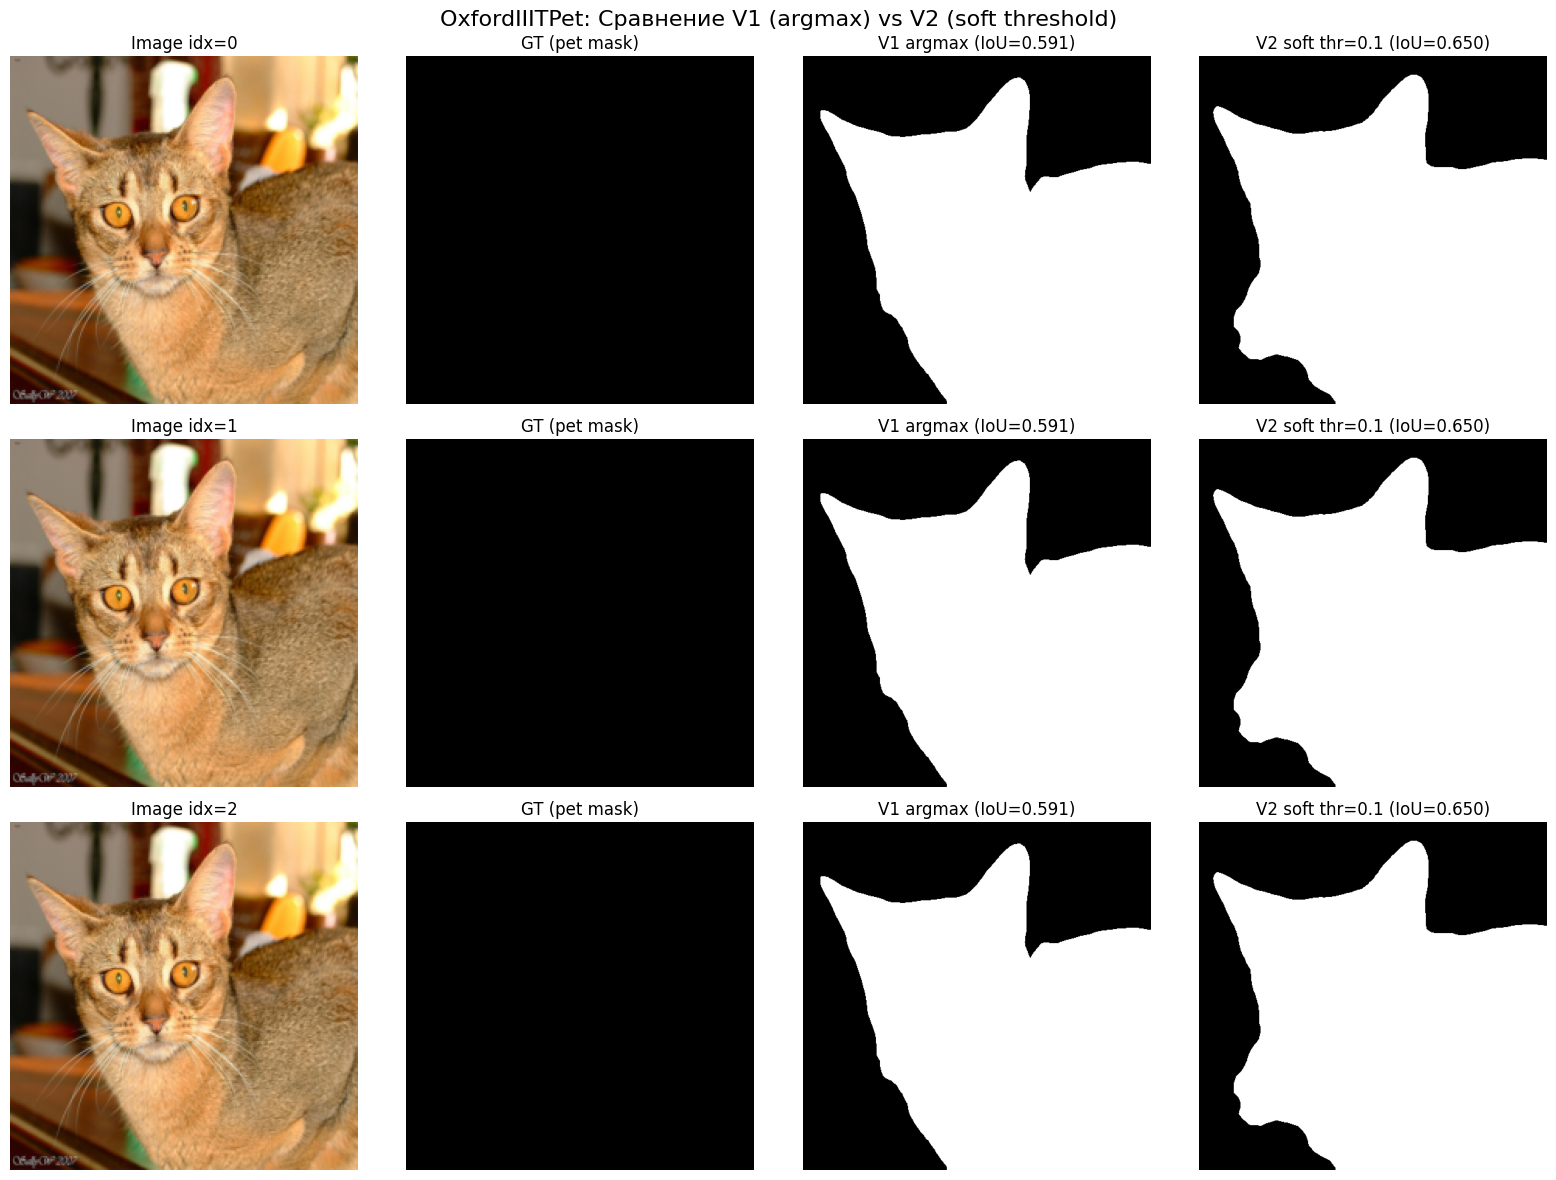

In [133]:
n = min(cfg.n_show, len(dataset_v))
fig, axes = plt.subplots(n, 4, figsize=(16, 4*n))

if n == 1:
    axes = np.expand_dims(axes, axis=0)

for row in range(n):
    img_pil, gt_np = dataset_v[row]

    # ========== Конвертация изображения для отображения ==========
    if isinstance(img_tensor, torch.Tensor):
        img_np = img_tensor.permute(1, 2, 0).cpu().numpy()
        img_np = img_np * 0.5 + 0.5  # Denormalize
        img_np = np.clip(img_np, 0, 1)
        img_pil = Image.fromarray((img_np * 255).astype(np.uint8))
    else:
        img_pil = img_tensor
    # V1: базовая постобработка
    pred_mask_v1, (h, w) = predict_pet_mask_v1(img_pil, threshold=0.5)
    # V2: альтернативная постобработка  
    pred_mask_v2, _ = predict_pet_mask_v2(img_pil, threshold=0.1)

    if isinstance(gt_np, torch.Tensor):
        gt_np = gt_np.cpu().numpy()
    if gt_np.ndim == 3 and gt_np.shape[0] == 1:
        gt_np = gt_np.squeeze(0)
        
    # GT resize to model space
    gt_pil = Image.fromarray((gt_np * 255).astype(np.uint8))
    gt_rs = resize(gt_pil, size=[h, w], interpolation=InterpolationMode.NEAREST)
    gt_mask = (torch.from_numpy(np.array(gt_rs)) > 0).to(torch.uint8)

    iou_v1 = iou_binary(pred_mask_v1, gt_mask)
    iou_v2 = iou_binary(pred_mask_v2, gt_mask)

    # Колонка 1: Исходное изображение
    axes[row, 0].imshow(img_pil)
    axes[row, 0].set_title(f"Image idx={row}")
    axes[row, 0].axis("off")

    # Колонка 2: GT маска
    axes[row, 1].imshow(gt_mask.numpy(), cmap="gray")
    axes[row, 1].set_title("GT (pet mask)")
    axes[row, 1].axis("off")

    # Колонка 3: V1 предсказание (argmax)
    axes[row, 2].imshow(pred_mask_v1.numpy(), cmap="gray")
    axes[row, 2].set_title(f"V1 argmax (IoU={iou_v1:.3f})")
    axes[row, 2].axis("off")

    # Колонка 4: V2 предсказание (soft threshold)
    axes[row, 3].imshow(pred_mask_v2.numpy(), cmap="gray")
    axes[row, 3].set_title(f"V2 soft thr=0.1 (IoU={iou_v2:.3f})")
    axes[row, 3].axis("off")

plt.suptitle("OxfordIIITPet: Сравнение V1 (argmax) vs V2 (soft threshold)", fontsize=16, y=0.98)
plt.tight_layout()
plt.savefig('artifacts/figures/segmentation_examples.png')

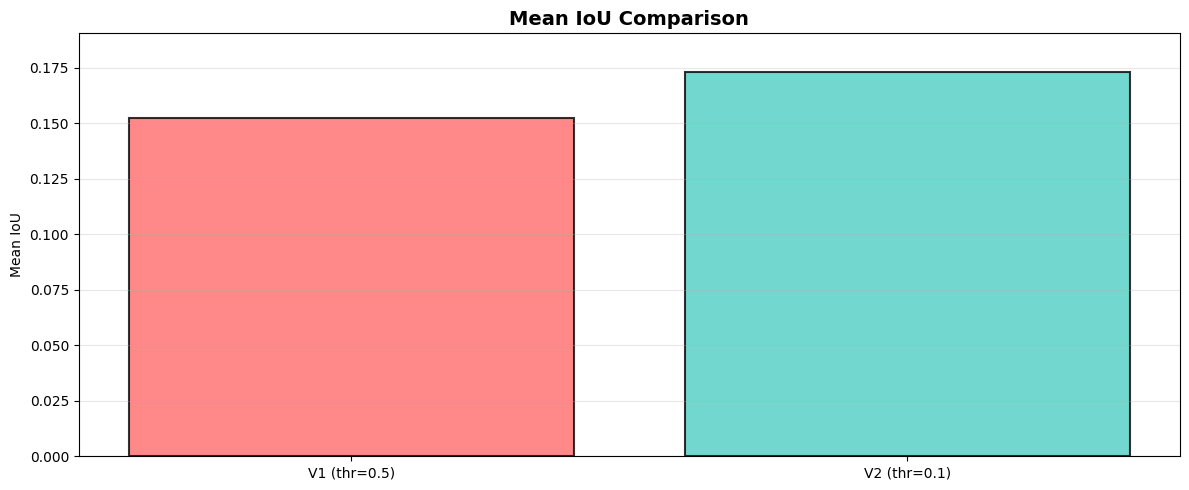

In [134]:
fig, ax = plt.subplots(1, 1, figsize=(12, 5))

# 1) Bar plot: mean IoU V1 vs V2
categories = ['V1 (thr=0.5)', 'V2 (thr=0.1)']
mean_ious = [metrics_v1['mean_IoU'], metrics_v2['mean_IoU']]

bars = ax.bar(categories, mean_ious, color=['#FF6B6B', '#4ECDC4'], 
               alpha=0.8, edgecolor='black', linewidth=1.5)
ax.set_title('Mean IoU Comparison', fontsize=14, fontweight='bold')
ax.set_ylabel('Mean IoU')
ax.set_ylim(0, max(mean_ious)*1.1)

ax.grid(True, alpha=0.3, axis='y')
plt.tight_layout()
plt.savefig('artifacts/figures/segmentation_metrics.png')